# Neuron Models

In this example we will look at different neuron models and plot their states over time.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from eventpropjax.evnn import FFEvNN
from eventpropjax.neuron_models import LIF, QIF

## LIF

Let's begin by creating a FFSNN using a LIF neuron.

In [2]:
key = jax.random.PRNGKey(0)

neurons = 5
snn = FFEvNN(
    layers=[neurons],
    in_size=1,
    neuron_model=LIF,
    max_solver_time=30.0,
    key=key,
    solver_stepsize=0.001,
    max_event_steps=2000,
    output_no_spike_value=jnp.inf,
    thresh=1.0,
    tsyn=5.0,
    tmem=20.0,
    init_bias=0.1,
    wlim=4.0,
    wmean=2.0
)

We will input a train of spikes with spikes at times $t=[0.0, 0.5, 1.0, 1.5, 2.0]$ and we will observe the internal states, here the membrane potential $V$ and the input current $I$ over 100 linear spaced out timepoints between $t \in [0, 10]$. Below we plot then plot each output neurons $V$ and $I$.

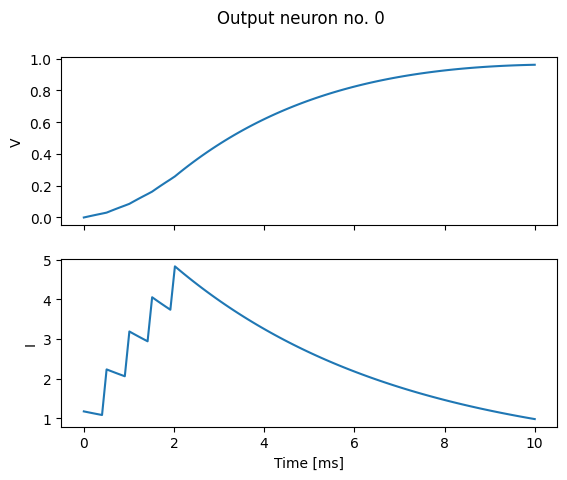

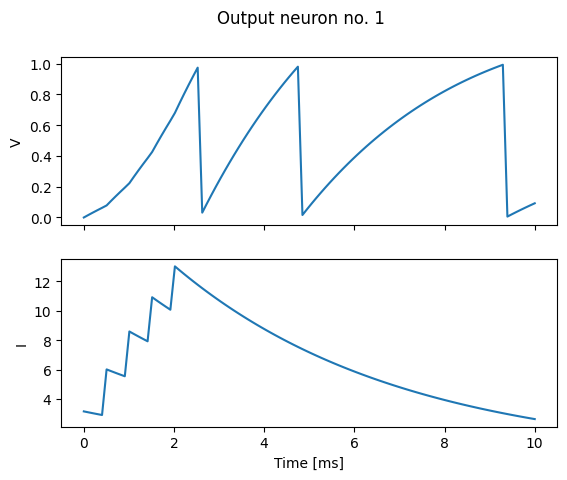

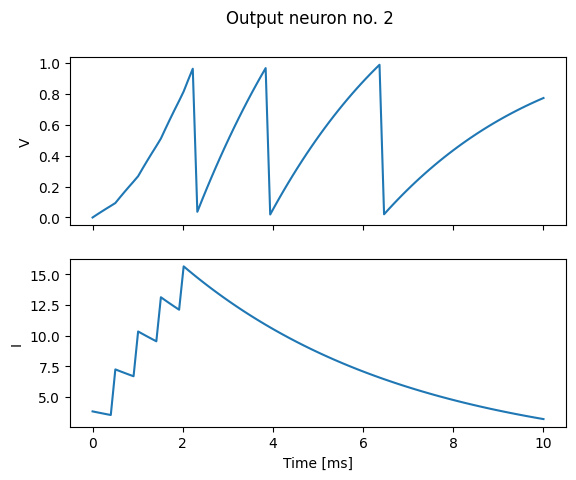

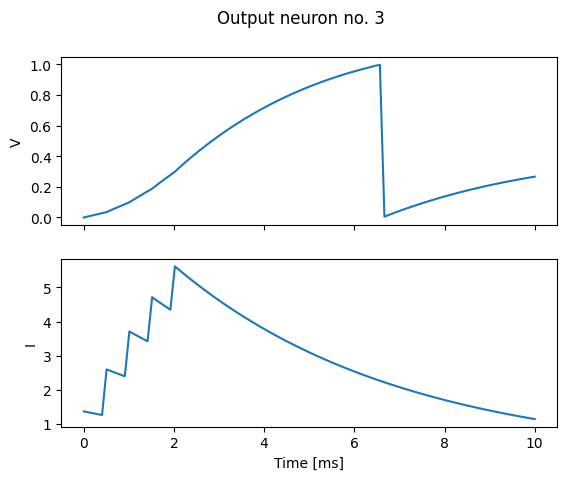

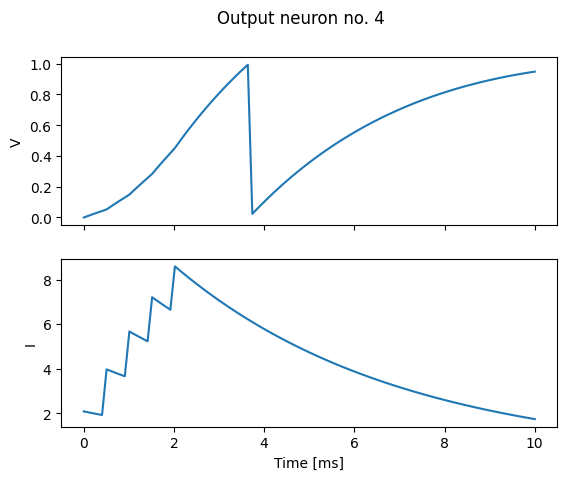

In [3]:
in_spikes = jnp.array([[0.0, 0.5, 1.0, 1.5, 2.0]])

times = jnp.linspace(0, 10.0, 100)

state_over_time = snn.state_at_t(in_spikes, times)

for i in range(state_over_time.shape[0]):
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    fig.suptitle(f"Output neuron no. {i}")
    ax2.set_xlabel("Time [ms]")
    ax1.set_ylabel("V")
    ax2.set_ylabel("I")
    ax1.plot(times, state_over_time[i, :, 0])
    ax2.plot(times, state_over_time[i, :, 1])

plt.show()

The input channels $I$ accumulate each incoming spike and gradually decay over time. The rate of change of the membrane potential depends on the current $I$. Once the potential reaches the threshold of 1, the neuron fires and then resets. The LIF here is defined by:

$$
\tau_{\text{mem}} \frac{dV}{dt} = -V + I
$$

$$
\tau_{\text{syn}} \frac{dI}{dt} = -I
$$

## QIF

Let's now look at the QIF neurons. We will proceed in the same manner. 
The QIF model is implemented in its angular (θ-neuron) representation, so the plotted membrane potential channel $V$ corresponds to the angular variable rather than the actual potential. The mapping is:
$$
V = \text{tan}\left(\frac{\pi \theta}{2}\right)
$$
In this library you pass the parameters of the `neuron_model` as keyword arguments to the SNN itself. Because the QIF has not threshold parameter like the LIF, we leave it out here.

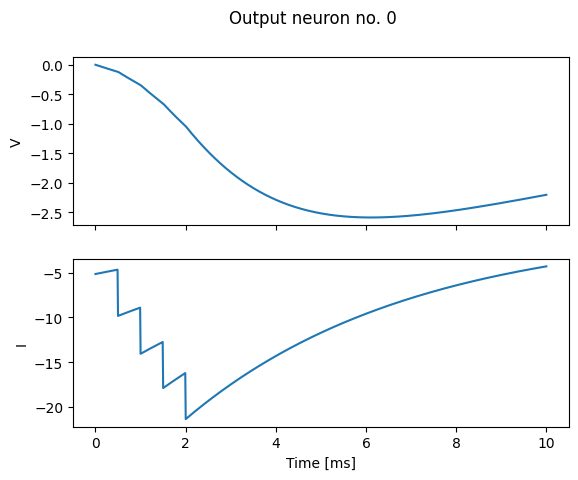

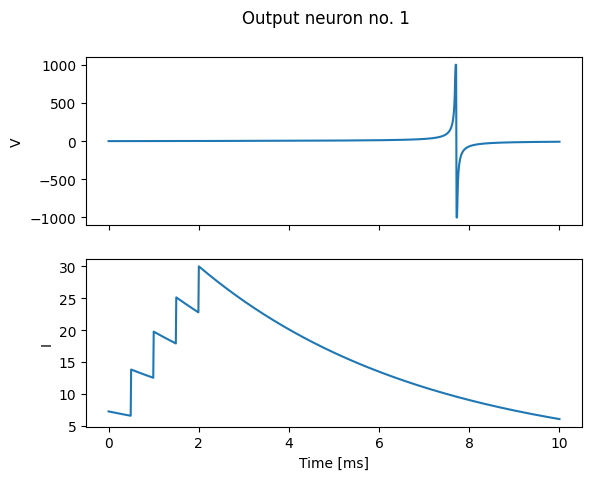

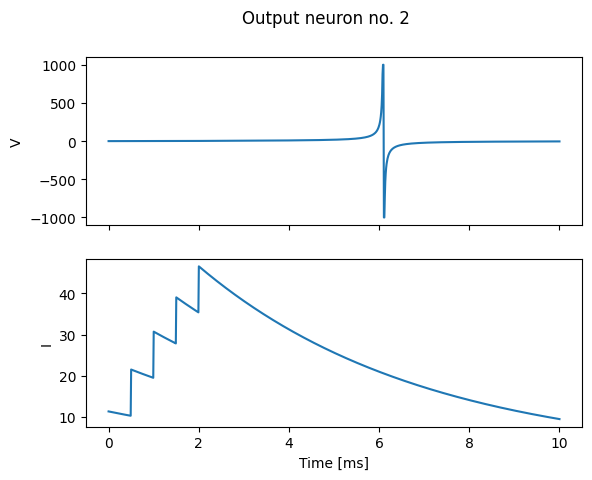

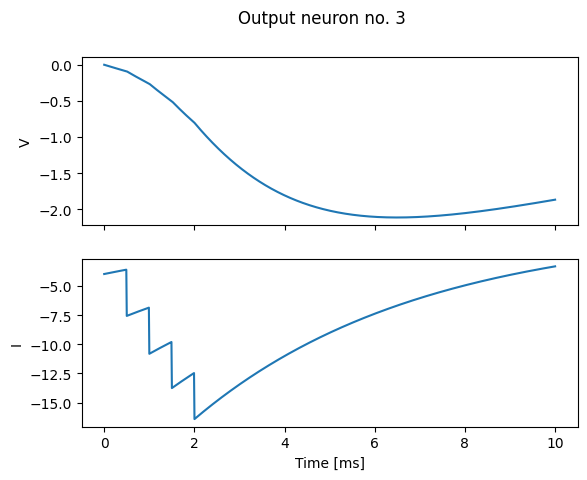

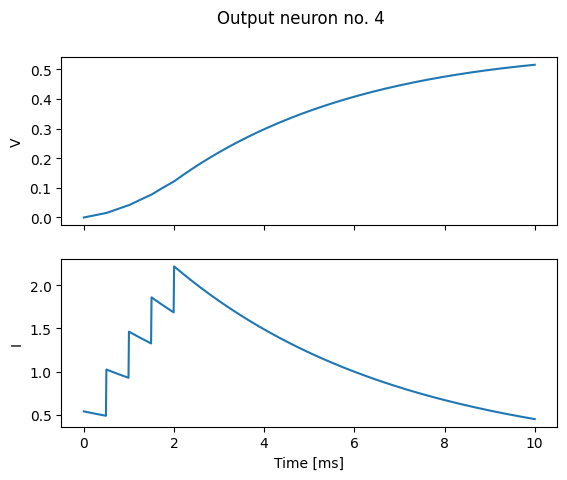

In [4]:
key = jax.random.PRNGKey(0)

neurons = 5
snn = FFEvNN(
    layers=[neurons],
    in_size=1,
    neuron_model=QIF,
    max_solver_time=30.0,
    key=key,
    solver_stepsize=0.001,
    max_event_steps=2000,
    output_no_spike_value=jnp.inf,
    tsyn=5.0,
    tmem=20.0,
    init_bias=0.1,
    wlim=25.0
)

in_spikes = jnp.array([[0.0, 0.5, 1.0, 1.5, 2.0]])

times = jnp.linspace(0, 10.0, 1000)

state_over_time = snn.state_at_t(in_spikes, times)

for i in range(state_over_time.shape[0]):
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    fig.suptitle(f"Output neuron no. {i}")
    ax2.set_xlabel("Time [ms]")
    ax1.set_ylabel("V")
    ax2.set_ylabel("I")
    V_plot = jnp.clip(state_over_time[i, :, 0], -1000.0, 1000.0)
    ax1.plot(times, V_plot)
    ax2.plot(times, state_over_time[i, :, 1])
    
plt.show()

## Custom Neuron Models

Lets now create a custom neuron model.
Every neuron model has the functions `__init__` to set the hyperparameters etc., `init_state` to initialize the internal state in some way, `dynamics`, which describe the dynamics, `spike_condition` that describes the condition under which the neuron spikes at, `input_spikes` which explains how incoming spikes influence the internal state, and `reset_spiked`, describing how the neuron state is adjusted after the neuron has spiked. You can introduce any amount of channels and hyperparameters, which then can be optimized easily. For simplicity of this tutorial, lets base it on the standard LIF and only change the dynamics to:

$$\dot{A} = \tau_{mem} (\text{sin}(A) + \text{cos}(B))$$
$$\tau_\text{syn} \dot{B} = -B$$

In [5]:
class FunkyNeuron(LIF):        
    def dynamics(self, t, y, args):
        a = y[:, 0]
        b = y[:, 1]
        da_dt = -(jnp.sin(a) + jnp.cos(b + self.ic)) * self.tmem.value
        db_dt = -b / self.tsyn.value
        return jnp.stack([da_dt, db_dt], axis=1)

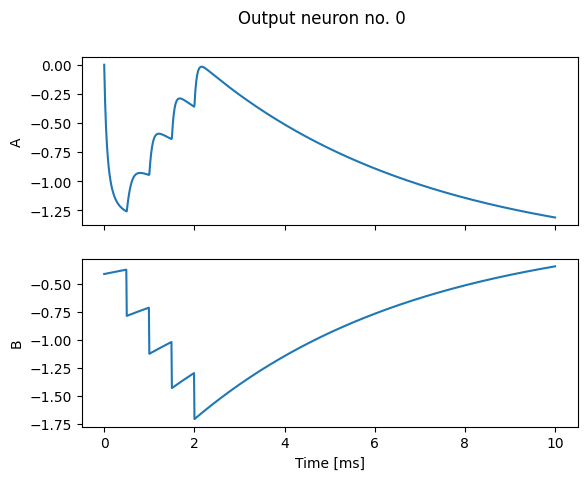

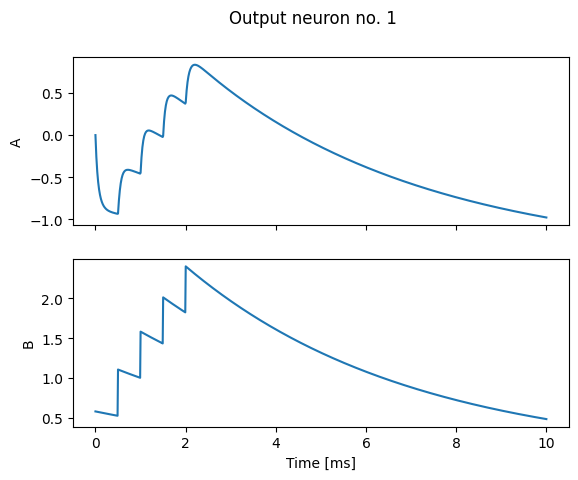

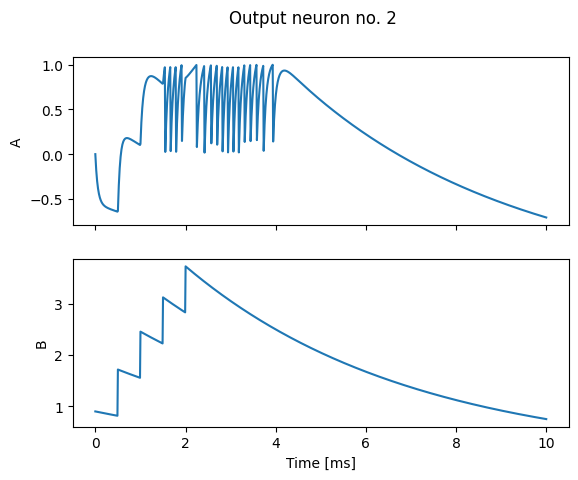

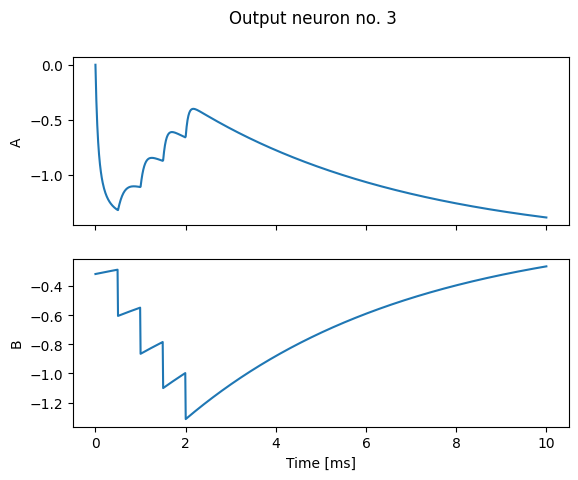

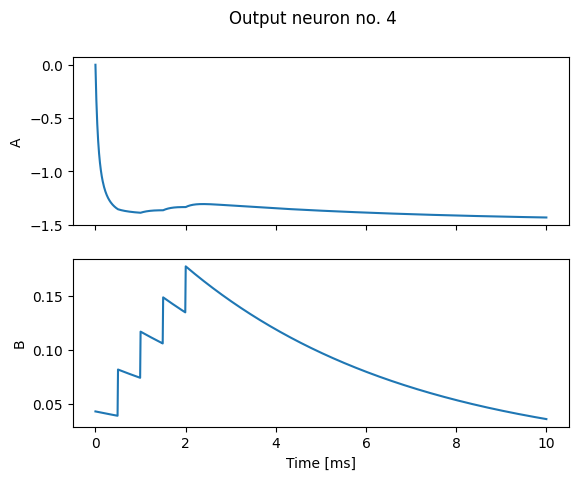

In [6]:
key = jax.random.PRNGKey(0)

neurons = 5
snn = FFEvNN(
    layers=[neurons],
    in_size=1,
    neuron_model=FunkyNeuron,
    max_solver_time=30.0,
    key=key,
    solver_stepsize=0.001,
    max_event_steps=2000,
    output_no_spike_value=jnp.inf,
    thresh=1.0,
    tsyn=5.0,
    tmem=20.0,
    init_bias=0.1,
    wlim=2.0
)

in_spikes = jnp.array([[0.0, 0.5, 1.0, 1.5, 2.0]])

times = jnp.linspace(0, 10.0, 1000)

state_over_time = snn.state_at_t(in_spikes, times)

for i in range(state_over_time.shape[0]):
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    fig.suptitle(f"Output neuron no. {i}")
    ax2.set_xlabel("Time [ms]")
    ax1.set_ylabel("A")
    ax2.set_ylabel("B")
    ax1.plot(times, state_over_time[i, :, 0])
    ax2.plot(times, state_over_time[i, :, 1])

plt.show()